wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/albert/.netrc.
wandb: Currently logged in as: albert-heinrichs-shop (ai-ml-universitaet-klagenfurt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loaded X: (54616, 512), y: (54616,)
Training LinearSVC... (This should be fast!)
Macro-F1: 0.3813
Weighted-F1: 0.4571


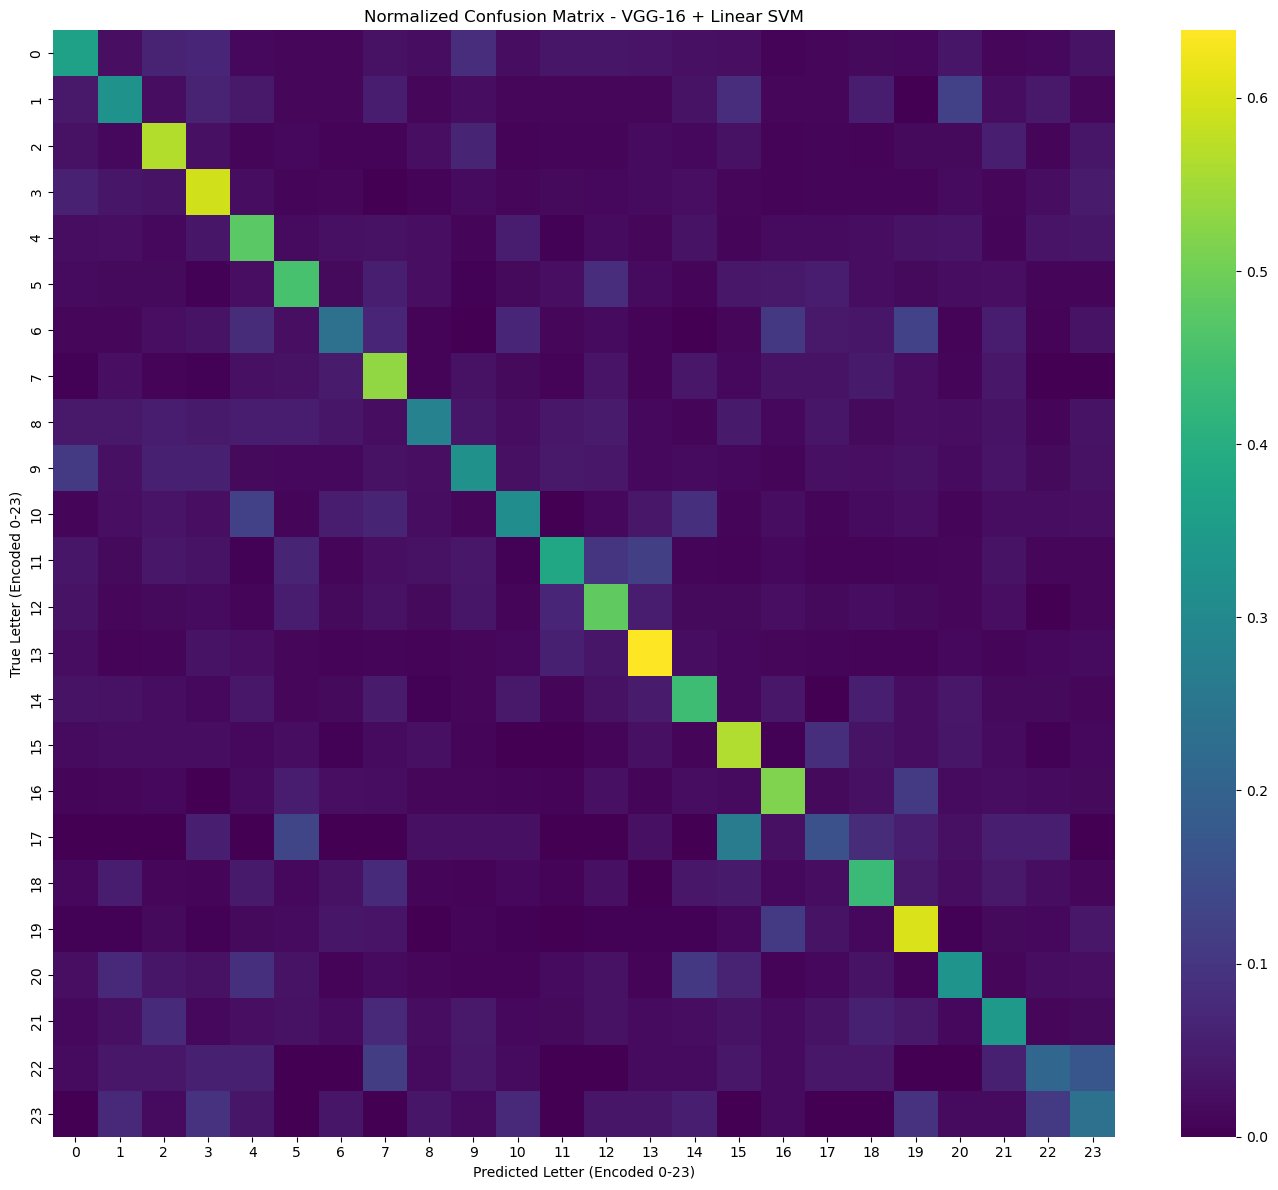


Classification Report (per class):
              precision    recall  f1-score   support

           0       0.60      0.37      0.45      1044
           1       0.11      0.32      0.17        99
           2       0.36      0.57      0.44       304
           3       0.45      0.59      0.51       378
           4       0.56      0.48      0.51       787
           5       0.48      0.45      0.46       533
           6       0.15      0.23      0.18       166
           7       0.39      0.53      0.45       433
           8       0.52      0.28      0.37       588
           9       0.30      0.32      0.31       355
          10       0.39      0.31      0.35       404
          11       0.44      0.38      0.41       479
          12       0.60      0.48      0.53       975
          13       0.55      0.64      0.59       543
          14       0.64      0.44      0.52       994
          15       0.35      0.56      0.43       224
          16       0.56      0.52      0.53  

macro_f1,▁
weighted_f1,▁
macro_f1,0.38132
weighted_f1,0.45715


In [1]:
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. Initialize Weights & Biases
wandb.init(project="odysseus", name="vgg16_linear_svm", job_type="modeling")

# 2. Load the extracted arrays
DATA_DIR = "../data/extracted_features"
X = np.load(f"{DATA_DIR}/X_features_vgg16.npy")
y = np.load(f"{DATA_DIR}/y_labels.npy")

print(f"Loaded X: {X.shape}, y: {y.shape}")

# 3. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # CRITICAL: Ensures rare classes are represented in test set
)

# 4. Standard Scaling (SVMs are highly sensitive to feature magnitude)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train the Linear SVM
print("Training LinearSVC... (This should be fast!)")
# class_weight='balanced' explicitly addresses your proposal's risk management
svm_clf = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

# 6. Predictions & Core Metrics
y_pred = svm_clf.predict(X_test_scaled)

# Calculate metrics mandated by the proposal (Macro-F1, Weighted-F1)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Macro-F1: {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")

# Log primary metrics to W&B
wandb.log({
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
})

# 7. Generate the 24x24 Normalized Confusion Matrix Heatmap
# Normalization avoids the dominance of large classes (e.g., Alpha)
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(16, 14))
# Using seaborn heatmap as proposed for the 24x24 grid
sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})

plt.title("Normalized Confusion Matrix - VGG-16 + Linear SVM")
plt.xlabel("Predicted Letter (Encoded 0-23)")
plt.ylabel("True Letter (Encoded 0-23)")
plt.tight_layout()

# Save the plot and log it to W&B
plt.savefig("svm_confusion_matrix.png", dpi=300)
wandb.log({"confusion_matrix": wandb.Image("svm_confusion_matrix.png")})
plt.show()

# 8. Detailed Classification Report (Precision, Recall, F1 for each class)
print("\nClassification Report (per class):")
print(classification_report(y_test, y_pred))

wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/albert/.netrc.
wandb: Currently logged in as: albert-heinrichs-shop (ai-ml-universitaet-klagenfurt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loaded X: (54616, 512), y: (54616,)
Training RBF Kernel SVC...
Training complete. Generating predictions...
Accuracy: 0.4834
Macro-F1: 0.4143
Weighted-F1: 0.4842


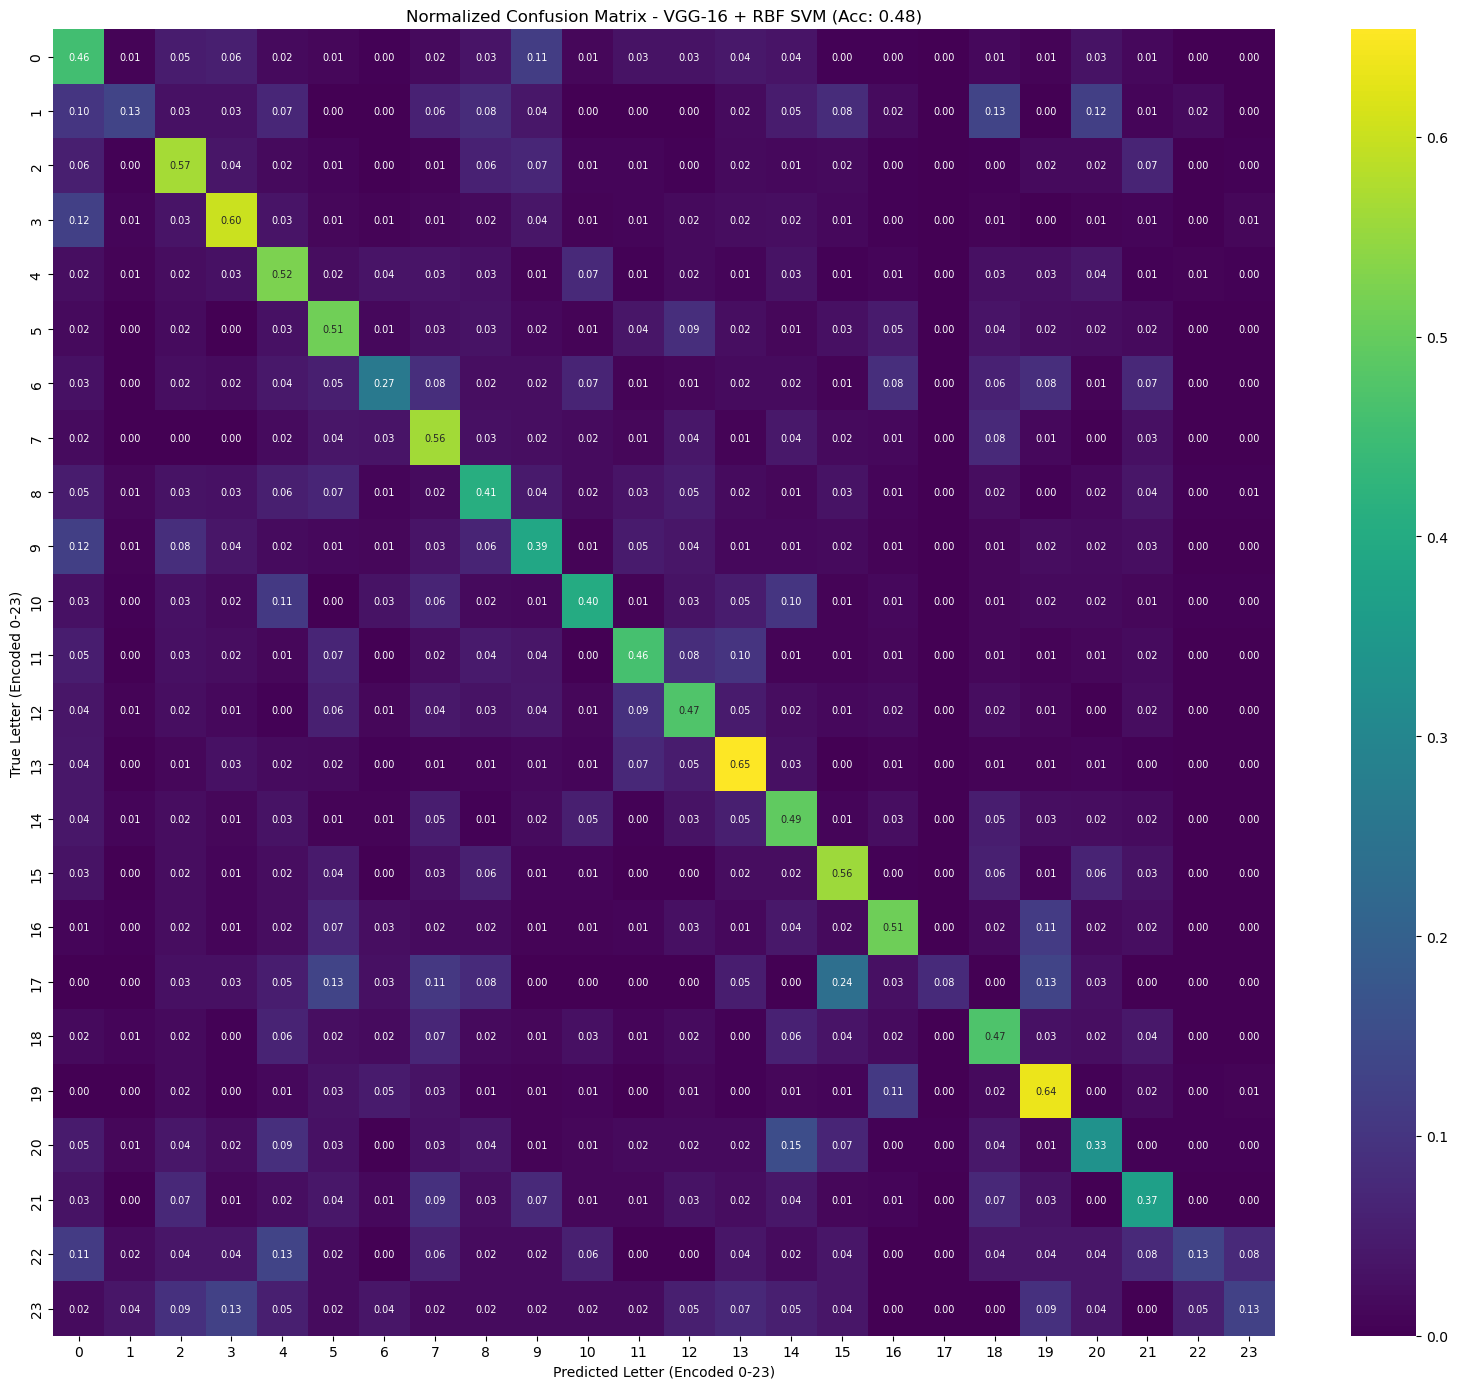


Classification Report (per class):
              precision    recall  f1-score   support

           0       0.56      0.46      0.50      1044
           1       0.18      0.13      0.15        99
           2       0.35      0.57      0.43       304
           3       0.51      0.60      0.55       378
           4       0.57      0.52      0.55       787
           5       0.45      0.51      0.48       533
           6       0.21      0.27      0.23       166
           7       0.40      0.56      0.47       433
           8       0.46      0.41      0.43       588
           9       0.28      0.39      0.33       355
          10       0.42      0.40      0.41       404
          11       0.46      0.46      0.46       479
          12       0.58      0.47      0.52       975
          13       0.53      0.65      0.59       543
          14       0.60      0.49      0.54       994
          15       0.42      0.56      0.48       224
          16       0.60      0.51      0.55  

final_accuracy,0.48343
final_macro_f1,0.4143
final_weighted_f1,0.48416


In [1]:
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# 1. Define hyperparameters centrally for W&B Config Tracking
# This dictionary will populate the "Overview" tab in your Weights & Biases dashboard.
config_params = {
    "model_type": "SVC",
    "kernel": "rbf",
    "C": 1.0,               # Regularization parameter
    "gamma": "scale",       # Kernel coefficient. 'scale' uses 1 / (n_features * X.var())
    "class_weight": "balanced", 
    "cache_size": 4000,     # CRITICAL: Allocates 4GB of Mac Unified Memory to the Gram matrix
    "test_size": 0.20,
    "random_state": 42
}

# 2. Initialize Weights & Biases with the config dictionary
wandb.init(project="odysseus", name="vgg16_rbf_svm", job_type="modeling", config=config_params)
# Map the tracked config back to a local variable for clean instantiation
config = wandb.config

# 3. Load the extracted arrays
DATA_DIR = "../data/extracted_features"
X = np.load(f"{DATA_DIR}/X_features_vgg16.npy")
y = np.load(f"{DATA_DIR}/y_labels.npy")

print(f"Loaded X: {X.shape}, y: {y.shape}")

# 4. Stratified Train-Test Split using tracked config parameters
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config.test_size, 
    random_state=config.random_state, 
    stratify=y
)

# 5. Standard Scaling (Even more critical for RBF kernels than Linear)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train the Non-Linear SVM
print("Training RBF Kernel SVC...")
svm_clf = SVC(
    kernel=config.kernel,
    C=config.C,
    gamma=config.gamma,
    class_weight=config.class_weight,
    cache_size=config.cache_size,
    random_state=config.random_state
)
svm_clf.fit(X_train_scaled, y_train)

# 7. Predictions
print("Training complete. Generating predictions...")
y_pred = svm_clf.predict(X_test_scaled)

# 8. Calculate Metrics
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")

# 9. Log Final Summary Metrics to W&B
# wandb.run.summary permanently pins these metrics to the table view in your dashboard
wandb.run.summary["final_accuracy"] = accuracy
wandb.run.summary["final_macro_f1"] = macro_f1
wandb.run.summary["final_weighted_f1"] = weighted_f1

# 10. Generate and Log Annotated Heatmap
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(16, 14))
# annot=True adds the probabilities to the cells
sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})

plt.title(f"Normalized Confusion Matrix - VGG-16 + RBF SVM (Acc: {accuracy:.2f})")
plt.xlabel("Predicted Letter (Encoded 0-23)")
plt.ylabel("True Letter (Encoded 0-23)")
plt.tight_layout()

plt.savefig("svm_rbf_confusion_matrix.png", dpi=300)
# Still logging the image using wandb.log() as files/images are best tracked this way
wandb.log({"confusion_matrix_annotated": wandb.Image("svm_rbf_confusion_matrix.png")})
plt.show()

print("\nClassification Report (per class):")
print(classification_report(y_test, y_pred))

# Close the W&B run
wandb.finish()

Loaded X: (54616, 256), y: (54616,)
Training RBF Kernel SVC...
Training complete. Generating predictions...
Accuracy: 0.3489
Macro-F1: 0.3019
Weighted-F1: 0.3524


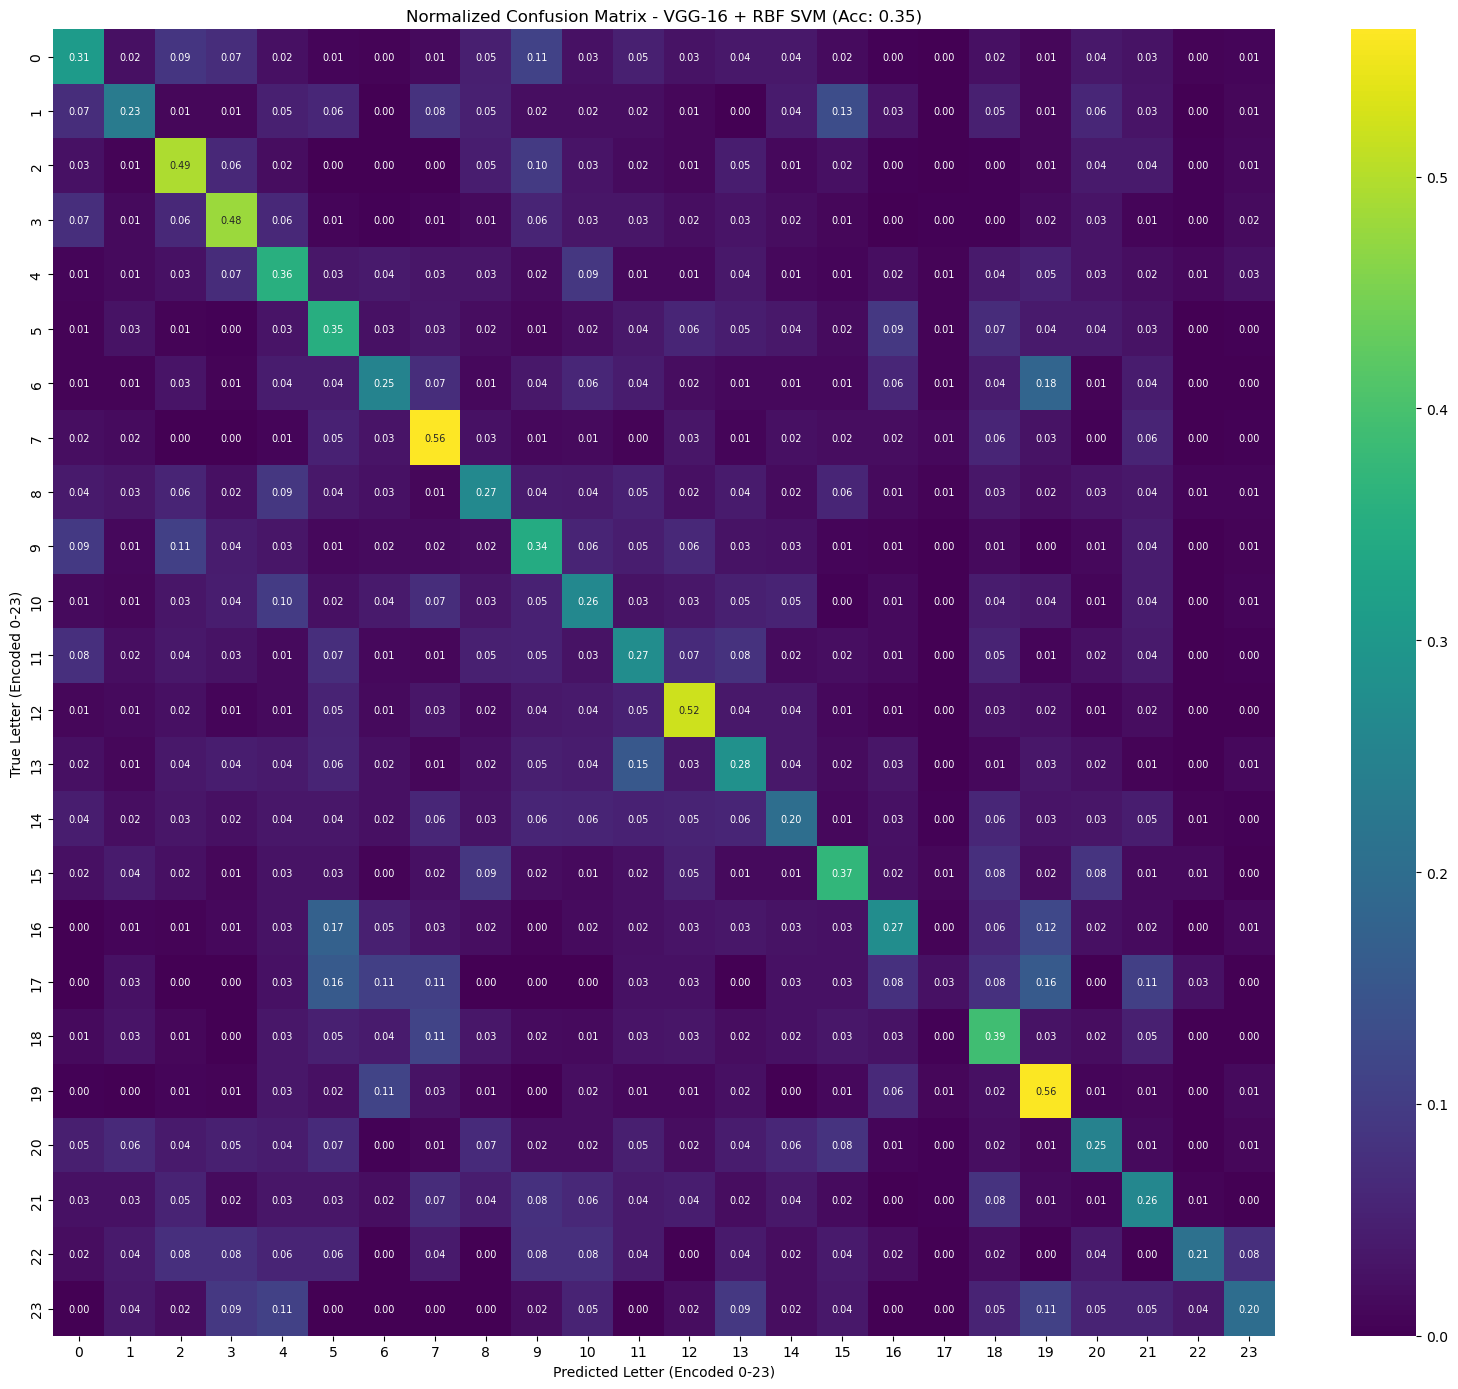


Classification Report (per class):
              precision    recall  f1-score   support

           0       0.55      0.31      0.39      1044
           1       0.10      0.23      0.14        99
           2       0.28      0.49      0.36       304
           3       0.37      0.48      0.42       378
           4       0.43      0.36      0.39       787
           5       0.29      0.35      0.32       533
           6       0.13      0.25      0.17       166
           7       0.40      0.56      0.47       433
           8       0.33      0.27      0.29       588
           9       0.21      0.34      0.26       355
          10       0.21      0.26      0.23       404
          11       0.24      0.27      0.25       479
          12       0.61      0.52      0.56       975
          13       0.29      0.28      0.29       543
          14       0.43      0.20      0.27       994
          15       0.27      0.37      0.31       224
          16       0.43      0.27      0.34  

final_accuracy,0.34886
final_macro_f1,0.30189
final_weighted_f1,0.35235


In [2]:
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# 1. Define hyperparameters centrally for W&B Config Tracking
# This dictionary will populate the "Overview" tab in your Weights & Biases dashboard.
config_params = {
    "model_type": "SVC",
    "kernel": "rbf",
    "C": 1.0,               # Regularization parameter
    "gamma": "scale",       # Kernel coefficient. 'scale' uses 1 / (n_features * X.var())
    "class_weight": "balanced", 
    "cache_size": 4000,     # CRITICAL: Allocates 4GB of Mac Unified Memory to the Gram matrix
    "test_size": 0.20,
    "random_state": 42,
    "vgg16_block": 3
}

# 2. Initialize Weights & Biases with the config dictionary
wandb.init(project="odysseus", name="vgg16_3blocks_rbf_svm", job_type="modeling", config=config_params)
# Map the tracked config back to a local variable for clean instantiation
config = wandb.config

# 3. Load the extracted arrays
DATA_DIR = "../data/extracted_features_early"
X = np.load(f"{DATA_DIR}/X_features_vgg16.npy")
y = np.load(f"{DATA_DIR}/y_labels.npy")

print(f"Loaded X: {X.shape}, y: {y.shape}")

# 4. Stratified Train-Test Split using tracked config parameters
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config.test_size, 
    random_state=config.random_state, 
    stratify=y
)

# 5. Standard Scaling (Even more critical for RBF kernels than Linear)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train the Non-Linear SVM
print("Training RBF Kernel SVC...")
svm_clf = SVC(
    kernel=config.kernel,
    C=config.C,
    gamma=config.gamma,
    class_weight=config.class_weight,
    cache_size=config.cache_size,
    random_state=config.random_state
)
svm_clf.fit(X_train_scaled, y_train)

# 7. Predictions
print("Training complete. Generating predictions...")
y_pred = svm_clf.predict(X_test_scaled)

# 8. Calculate Metrics
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")

# 9. Log Final Summary Metrics to W&B
# wandb.run.summary permanently pins these metrics to the table view in your dashboard
wandb.run.summary["final_accuracy"] = accuracy
wandb.run.summary["final_macro_f1"] = macro_f1
wandb.run.summary["final_weighted_f1"] = weighted_f1

# 10. Generate and Log Annotated Heatmap
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(16, 14))
# annot=True adds the probabilities to the cells
sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})

plt.title(f"Normalized Confusion Matrix - VGG-16 + RBF SVM (Acc: {accuracy:.2f})")
plt.xlabel("Predicted Letter (Encoded 0-23)")
plt.ylabel("True Letter (Encoded 0-23)")
plt.tight_layout()

plt.savefig("svm_rbf_confusion_matrix.png", dpi=300)
# Still logging the image using wandb.log() as files/images are best tracked this way
wandb.log({"confusion_matrix_annotated": wandb.Image("svm_rbf_confusion_matrix.png")})
plt.show()

print("\nClassification Report (per class):")
print(classification_report(y_test, y_pred))

# Close the W&B run
wandb.finish()

Loaded X: (125280, 2048), y: (125280,)
Training RBF Kernel SVC on 2048-D SPP features...
Accuracy: 0.6750
Macro-F1: 0.6738


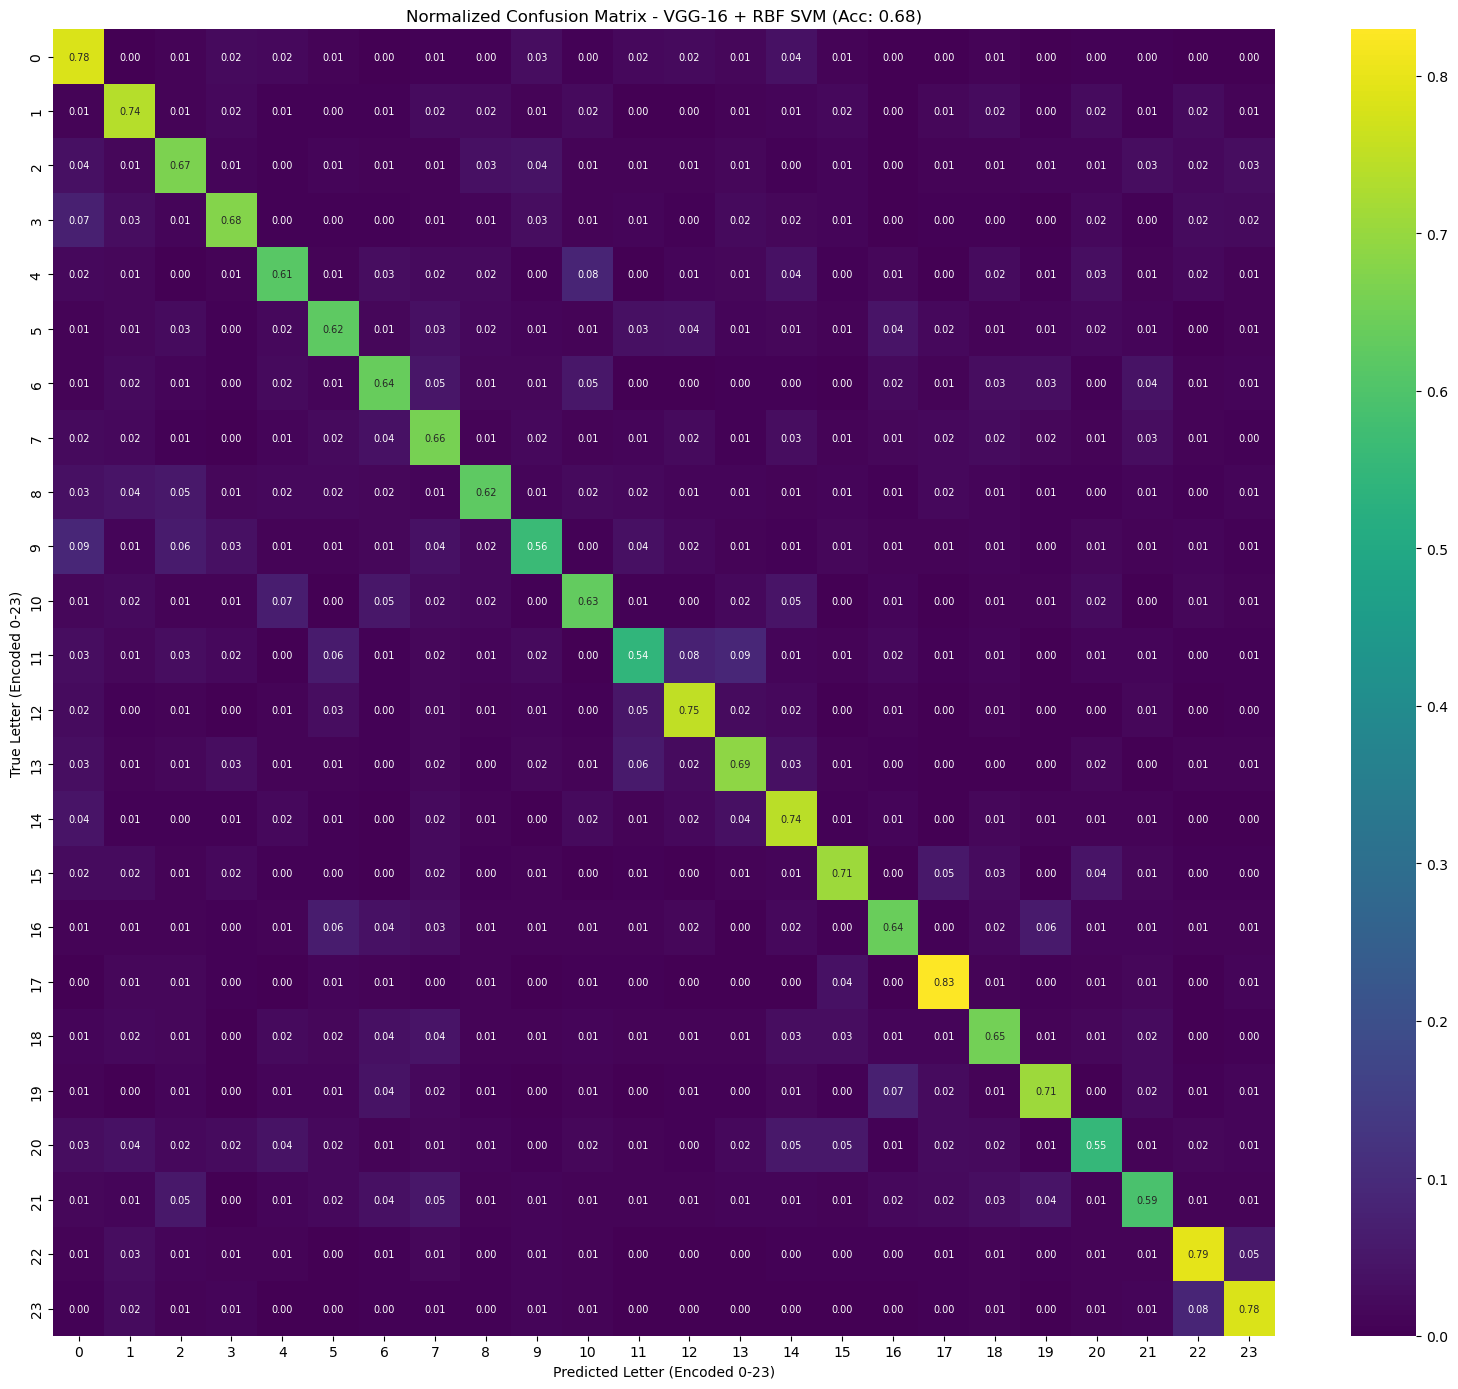

              precision    recall  f1-score   support

           0       0.59      0.78      0.68      1044
           1       0.66      0.74      0.70      1044
           2       0.62      0.67      0.64      1044
           3       0.73      0.68      0.70      1044
           4       0.65      0.61      0.63      1044
           5       0.64      0.62      0.63      1044
           6       0.64      0.64      0.64      1044
           7       0.58      0.66      0.62      1044
           8       0.71      0.62      0.66      1044
           9       0.66      0.56      0.61      1044
          10       0.66      0.63      0.64      1044
          11       0.64      0.54      0.59      1044
          12       0.71      0.75      0.73      1044
          13       0.67      0.69      0.68      1044
          14       0.64      0.74      0.69      1044
          15       0.73      0.71      0.72      1044
          16       0.69      0.64      0.67      1044
          17       0.76    

final_accuracy,0.67501
final_macro_f1,0.67379


In [2]:
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# 1. Update Config for W&B
config_params = {
    "model_type": "SVC",
    "kernel": "rbf",
    "C": 1.0,               
    "gamma": "scale",       
    "class_weight": None,   # Dataset is now physically balanced with artificially augmented data
    "pooling_strategy": "SPP_2x2",
    "feature_dimensions": 2048,
    "cache_size": 4000,     # M3 Mac memory allocation
    "test_size": 0.20,
    "random_state": 42
}

wandb.init(project="odysseus", name="vgg16_spp2x2_augmented_rbf", job_type="modeling", config=config_params)
config = wandb.config

# 2. Load the NEW SPP 2048-dimensional arrays
DATA_DIR = "../data/extracted_features_SPP"
X = np.load(f"{DATA_DIR}/X_features_vgg16.npy")
y = np.load(f"{DATA_DIR}/y_labels.npy")

print(f"Loaded X: {X.shape}, y: {y.shape}")

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.test_size, random_state=config.random_state, stratify=y
)

# 4. Standard Scaling (Crucial for 2048-d vectors)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train the SVM (No class weights)
print("Training RBF Kernel SVC on 2048-D SPP features...")
svm_clf = SVC(
    kernel=config.kernel,
    C=config.C,
    gamma=config.gamma,
    class_weight=config.class_weight,
    cache_size=config.cache_size,
    random_state=config.random_state
)
svm_clf.fit(X_train_scaled, y_train)

# 6. Evaluate and Log
y_pred = svm_clf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")

wandb.run.summary["final_accuracy"] = accuracy
wandb.run.summary["final_macro_f1"] = macro_f1

# 10. Generate and Log Annotated Heatmap
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(16, 14))
# annot=True adds the probabilities to the cells
sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})

plt.title(f"Normalized Confusion Matrix - VGG-16 + RBF SVM (Acc: {accuracy:.2f})")
plt.xlabel("Predicted Letter (Encoded 0-23)")
plt.ylabel("True Letter (Encoded 0-23)")
plt.tight_layout()

plt.savefig("svm_rbf_confusion_matrix.png", dpi=300)
# Still logging the image using wandb.log() as files/images are best tracked this way
wandb.log({"confusion_matrix_annotated": wandb.Image("svm_rbf_confusion_matrix.png")})
plt.show()

print(classification_report(y_test, y_pred))
wandb.finish()